# bitnet sanity sweep — gemma-3-270m

before i write the actual converter (gptq + hadamard + ternary), i want to know what the floor looks like. just RTN at different bitwidths, applied to one component group at a time, and see which parts of the model break first.

so this notebook is basically a diagnostic / research log. nothing here is meant to be a finished compressor yet.

i first got the pipeline running locally and used it to check that the model loads, quantizes, and gives sensible baseline perplexity numbers. local runs worked, but repeated sweeps were slow. i had some colab credits left from a course, so i used colab to fast-track the heavier sweep / ablation part instead of waiting on local hardware.

what i’m running:
- bf16 baseline (reference)
- int8, int4 (group=128), 1.58-bit ternary (absmean), 1-bit (sign × absmean)
- two scopes: "all linears, embed stays bf16" vs "everything"
- component sensitivity: embed, qkv, attn_o, mlp_in, mlp_out
- paper-inspired sub-2-bit PTQ baselines
- my own mixed-precision ternary stack with saliency rescue + bias correction
- simplified GPTQ / Hadamard sanity baselines

important: this is fake quantization. weights are quantized and then dequantized back for evaluation. so this measures accuracy / perplexity damage from low-bit weights, not real inference speed or kernel-level memory savings.

also important: the paper methods below are simplified paper-inspired baselines, not full official replications. the goal is to understand what breaks on gemma-270m and which ideas actually move perplexity.

## status

status: in progress / research prototype

this notebook is not trying to be a polished benchmark yet. it is more like a lab notebook:

1. build the evaluation path
2. run simple baselines
3. test simplified versions of paper ideas
4. see where they fail
5. use the failures to design the next converter

current result:

plain sub-2-bit PTQ is too fragile on gemma-270m. the only sub-2-bit direction that looks promising so far is mixed precision: ternary for most weights, plus saliency-based INT4 rescue for important weights.

next direction:

turn this into a cleaner quantization pipeline with proper GPTQ, real rotation folding, layerwise saliency schedules, and actual low-bit storage / inference tests.

In [1]:
!pip -q install -U transformers accelerate huggingface_hub 2>&1 | tail -3
!pip -q install matplotlib 2>&1 | tail -1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 158.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 59.2 MB/s eta 0:00:00


In [5]:
import os, time, math, json, gc
from pathlib import Path
import urllib.request

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login

# gemma is gated. add HF_TOKEN as a colab secret or paste below
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN', '')

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print('hf login ok')
else:
    print('no token — call login() manually if you hit a 401')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)
print(device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

hf login ok
cuda NVIDIA A100-SXM4-40GB


In [6]:
# wikitext-2 valid, same as my baseline runs
WIKITEXT_URL = 'https://cosmo.zip/pub/datasets/wikitext-2-raw/wiki.valid.raw'
val_path = Path('wiki.valid.raw')
if not val_path.exists():
    req = urllib.request.Request(WIKITEXT_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as r, open(val_path, 'wb') as f:
        f.write(r.read())
print(val_path.stat().st_size, 'bytes')

1146846 bytes


## load model + look at where the params actually live

In [7]:
MODEL_ID = 'google/gemma-3-270m'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def fresh_model():
    # need a clean copy for each ablation run, otherwise quantization stacks
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map={'': device},
        attn_implementation='eager',
    )
    m.eval()
    return m

base = fresh_model()
print(base.config)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "dtype": "bfloat16",
  "eos_token_id": 1,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 640,
  "initializer_range": 0.02,
  "intermediate_size": 2048,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "full_attention"
  ],
  "max_position_embeddings": 32768,
  "model_type": "gemma3_text",
  "num_attention_heads": 4,
  "num_h

In [8]:
# i want to know what fraction of the model is embed/head vs the actual transformer
# (claude told me it's like 60%+ but i should verify)

def categorize(name):
    if 'embed_tokens' in name or name.endswith('lm_head') or name.endswith('lm_head.weight'):
        return 'embed/head'
    if any(k in name for k in ['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj']):
        return 'attn_qkv'
    if 'self_attn.o_proj' in name:
        return 'attn_o'
    if 'mlp.gate_proj' in name or 'mlp.up_proj' in name:
        return 'mlp_in'
    if 'mlp.down_proj' in name:
        return 'mlp_out'
    if 'norm' in name.lower():
        return 'norm'
    return 'other'

total = 0
breakdown = {}
for name, p in base.named_parameters():
    total += p.numel()
    cat = categorize(name)
    breakdown[cat] = breakdown.get(cat, 0) + p.numel()

print(f'total: {total:,} params, {total*2/1024**2:.1f} MB at bf16')
for k, v in sorted(breakdown.items(), key=lambda x: -x[1]):
    print(f'  {k:12s} {v:>12,}  {100*v/total:5.1f}%')

total: 268,098,176 params, 511.4 MB at bf16
  embed/head    167,772,160   62.6%
  mlp_in         47,185,920   17.6%
  mlp_out        23,592,960    8.8%
  attn_qkv       17,694,720    6.6%
  attn_o         11,796,480    4.4%
  norm               55,936    0.0%


## quantizers — just RTN

these are all round-to-nearest. nothing data-aware yet (that's GPTQ, separate notebook). per-row scales for int8, group-wise scales for int4 (g=128, like NF4-ish). ternary is bitnet b1.58's absmean formula. binary is sign × mean(|w|).

each function returns a bf16 tensor with the lossy values baked in. fake-quant — measures the error, not the storage savings.


In [9]:
@torch.no_grad()
def q_int8(W):
    # per-row symmetric
    Wf = W.float()
    absmax = Wf.abs().amax(dim=1, keepdim=True).clamp(min=1e-8)
    scale = absmax / 127.0
    Wq = (Wf / scale).round().clamp(-128, 127)
    return (Wq * scale).to(torch.bfloat16)

@torch.no_grad()
def q_int4_g128(W, group_size=128):
    Wf = W.float()
    out, inn = Wf.shape
    # pad if not divisible — easiest workaround
    pad = (group_size - inn % group_size) % group_size
    if pad:
        Wf = torch.cat([Wf, torch.zeros(out, pad, device=Wf.device)], dim=1)
    Wg = Wf.reshape(out, -1, group_size)
    absmax = Wg.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
    scale = absmax / 7.0
    Wq = (Wg / scale).round().clamp(-8, 7)
    Wdq = (Wq * scale).reshape(out, -1)
    if pad:
        Wdq = Wdq[:, :inn]
    return Wdq.to(torch.bfloat16)

@torch.no_grad()
def q_ternary_absmean(W):
    # bitnet b1.58: gamma = mean(|W|) over the whole tensor
    Wf = W.float()
    gamma = Wf.abs().mean().clamp(min=1e-8)
    Wq = (Wf / gamma).round().clamp(-1, 1)
    return (Wq * gamma).to(torch.bfloat16)

@torch.no_grad()
def q_binary_signmean(W):
    # 1-bit: alpha = mean(|W|), W_dq = alpha * sign(W)
    Wf = W.float()
    alpha = Wf.abs().mean().clamp(min=1e-8)
    Wq = Wf.sign()
    Wq = torch.where(Wq == 0, torch.ones_like(Wq), Wq)  # tie-break exact zeros to +1
    return (Wq * alpha).to(torch.bfloat16)

@torch.no_grad()
def q_identity(W):
    return W.to(torch.bfloat16)

QUANTIZERS = {
    'bf16':      q_identity,
    'int8':      q_int8,
    'int4_g128': q_int4_g128,
    'ternary':   q_ternary_absmean,
    'binary':    q_binary_signmean,
}

BITS = {'bf16': 16, 'int8': 8, 'int4_g128': 4, 'ternary': 1.58, 'binary': 1.0}

## apply quantizer to a chosen subset of modules

groups i care about:
- `embed` — embed_tokens + lm_head (tied, but show up as separate names sometimes)
- `attn_qkv` — q/k/v projections
- `attn_o` — output projection (writes to residual stream — sensitive)
- `mlp_in` — gate_proj + up_proj
- `mlp_out` — down_proj (also writes to residual stream)
- `all_linear` — everything except embed
- `all` — literally everything

In [10]:
def in_group(name, group):
    if group == 'embed':
        return 'embed_tokens' in name or name == 'lm_head'
    if group == 'attn_qkv':
        return any(k in name for k in ['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj'])
    if group == 'attn_o':
        return 'self_attn.o_proj' in name
    if group == 'mlp_in':
        return 'mlp.gate_proj' in name or 'mlp.up_proj' in name
    if group == 'mlp_out':
        return 'mlp.down_proj' in name
    if group == 'all_linear':
        return not ('embed_tokens' in name or name == 'lm_head')
    if group == 'all':
        return True
    return False

@torch.no_grad()
def apply_quant(model, groups, method):
    qfn = QUANTIZERS[method]
    n = 0
    for name, mod in model.named_modules():
        if isinstance(mod, (nn.Linear, nn.Embedding)):
            if any(in_group(name, g) for g in groups):
                w = mod.weight.data
                if w.dim() != 2:
                    continue
                # embeddings: same per-row idea for int8, otherwise just use the same fn
                if isinstance(mod, nn.Embedding):
                    if method == 'int8':
                        absmax = w.float().abs().amax(dim=1, keepdim=True).clamp(min=1e-8)
                        s = absmax / 127.0
                        wq = (w.float()/s).round().clamp(-128,127)
                        mod.weight.data = (wq * s).to(torch.bfloat16)
                    else:
                        mod.weight.data = qfn(w).to(torch.bfloat16)
                else:
                    mod.weight.data = qfn(w).to(torch.bfloat16)
                n += 1
    return n

## perplexity — same setup as my baseline runs

512-token chunks, batch 4, no overlap. matches what i had in `src/eval/perplexity.py`.

In [11]:
@torch.no_grad()
def perplexity(model, tokenizer, text_path='wiki.valid.raw', seq_len=512, batch=4):
    with open(text_path, 'r', encoding='utf-8') as f:
        text = f.read()
    enc = tokenizer(text, return_tensors=None, add_special_tokens=False)
    ids = enc['input_ids']
    if isinstance(ids[0], list):
        ids = sum(ids, [])
    chunks = [ids[i:i+seq_len] for i in range(0, len(ids)-seq_len, seq_len)]
    total_loss, total_tokens = 0.0, 0
    model.eval()
    t0 = time.perf_counter()
    for i in range(0, len(chunks), batch):
        b = chunks[i:i+batch]
        x = torch.tensor(b, dtype=torch.long, device=device)
        out = model(input_ids=x, labels=x, use_cache=False)
        n = x.numel()
        total_loss += out.loss.item() * n
        total_tokens += n
    elapsed = time.perf_counter() - t0
    return math.exp(total_loss/total_tokens), total_tokens/elapsed, total_tokens

In [12]:
# theoretical compressed size — groups at the chosen bitwidth, everything else bf16.
# include scale overhead for int8/int4 because at low bitwidths it actually matters.
# ternary/binary scales: 1 scalar per tensor, basically zero.

def compressed_size_mb(model, groups, method):
    bits_q = BITS[method]
    bytes_total = 0.0
    for name, mod in model.named_modules():
        if isinstance(mod, (nn.Linear, nn.Embedding)):
            n = mod.weight.numel()
            if any(in_group(name, g) for g in groups):
                bytes_total += n * bits_q / 8
                if method == 'int4_g128':
                    out_dim, in_dim = mod.weight.shape
                    n_groups = out_dim * ((in_dim + 127)//128)
                    bytes_total += n_groups * 2  # bf16 scale per group
                elif method == 'int8':
                    bytes_total += mod.weight.shape[0] * 2  # per-row scale
            else:
                bytes_total += n * 2
    # norms always bf16
    for name, p in model.named_parameters():
        if 'norm' in name.lower():
            bytes_total += p.numel() * 2
    return bytes_total / (1024**2)

## baseline first

In [13]:
print('--- bf16 baseline ---')
ppl_bf16, tps_bf16, ntok = perplexity(base, tokenizer)
size_bf16 = compressed_size_mb(base, ['all'], 'bf16')
print(f'ppl={ppl_bf16:.4f}  size={size_bf16:.2f} MB  tokens={ntok}')

results = [{
    'label': 'bf16',
    'method': 'bf16', 'group': 'none',
    'ppl': ppl_bf16, 'size_mb': size_bf16, 'bits': 16
}]

--- bf16 baseline ---
ppl=56.6821  size=831.36 MB  tokens=259584


## the sweep

~18 runs. each loads a fresh model, quantizes one config, evaluates, frees. ~30-45 min on T4, much faster on A100.

A: all linears (embed stays bf16) at every bitwidth — the "transformer body only" curve  
B: everything including embed — shows how much the embed dominates  
C: per-group sensitivity at ternary  
D: per-group sensitivity at binary  


In [14]:
def run_one(group_list, method, label):
    m = fresh_model()
    n = apply_quant(m, group_list, method)
    size = compressed_size_mb(m, group_list, method)
    ppl, _, _ = perplexity(m, tokenizer)
    print(f'{label:42s} | ppl={ppl:9.3f} | size={size:6.2f} MB | quantized={n}')
    del m
    gc.collect()
    torch.cuda.empty_cache()
    return {
        'label': label, 'method': method, 'group': '+'.join(group_list),
        'ppl': float(ppl), 'size_mb': float(size), 'bits': BITS[method]
    }

# A: all linears, embed stays bf16
print('\n[A] all_linear (embed bf16)')
for meth in ['int8', 'int4_g128', 'ternary', 'binary']:
    results.append(run_one(['all_linear'], meth, f'A: all_linear @ {meth}'))

# B: everything including embed
print('\n[B] all (incl embed)')
for meth in ['int8', 'int4_g128', 'ternary', 'binary']:
    results.append(run_one(['all'], meth, f'B: all @ {meth}'))

# C: per-component @ ternary
print('\n[C] only one group @ ternary')
for grp in ['embed', 'attn_qkv', 'attn_o', 'mlp_in', 'mlp_out']:
    results.append(run_one([grp], 'ternary', f'C: only {grp} @ ternary'))

# D: per-component @ binary
print('\n[D] only one group @ binary')
for grp in ['embed', 'attn_qkv', 'attn_o', 'mlp_in', 'mlp_out']:
    results.append(run_one([grp], 'binary', f'D: only {grp} @ binary'))

# save for plotting / cross-ref with my other baseline jsonls
with open('results.jsonl', 'w') as f:
    for r in results:
        f.write(json.dumps(r) + '\n')
print(f'saved {len(results)} runs to results.jsonl')


[A] all_linear (embed bf16)


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

A: all_linear @ int8                       | ppl=   61.333 | size=735.97 MB | quantized=126


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

A: all_linear @ int4_g128                  | ppl=  104.054 | size=689.41 MB | quantized=126


...

D: only attn_o @ binary                    | ppl=16141459.912 | size=810.26 MB | quantized=18


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

D: only mlp_in @ binary                    | ppl=1627690044.726 | size=746.98 MB | quantized=36


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

D: only mlp_out @ binary                   | ppl=107635772.998 | size=789.17 MB | quantized=18
saved 19 runs to results.jsonl


## results

In [15]:
# table
print(f"{'label':45s} {'ppl':>10s} {'size_MB':>10s} {'bits':>6s}")
print('-' * 75)
for r in results:
    print(f"{r['label']:45s} {r['ppl']:10.3f} {r['size_mb']:10.2f} {r['bits']:>6}")

label                                                ppl    size_MB   bits
---------------------------------------------------------------------------
bf16                                              56.682     831.36     16
A: all_linear @ int8                              61.333     735.97      8
A: all_linear @ int4_g128                        104.054     689.41      4
A: all_linear @ ternary                       2297785640.666     658.99   1.58
A: all_linear @ binary                        84145565286.669     652.06    1.0
B: all @ int8                                     61.521     416.97      8
B: all @ int4_g128                               135.593     214.41      4
B: all @ ternary                              2023972.946      82.19   1.58
B: all @ binary                               50332207420.207      52.06    1.0
C: only embed @ ternary                        74041.338     254.56   1.58
C: only attn_qkv @ ternary                      4154.387     800.94   1.58
C: only a

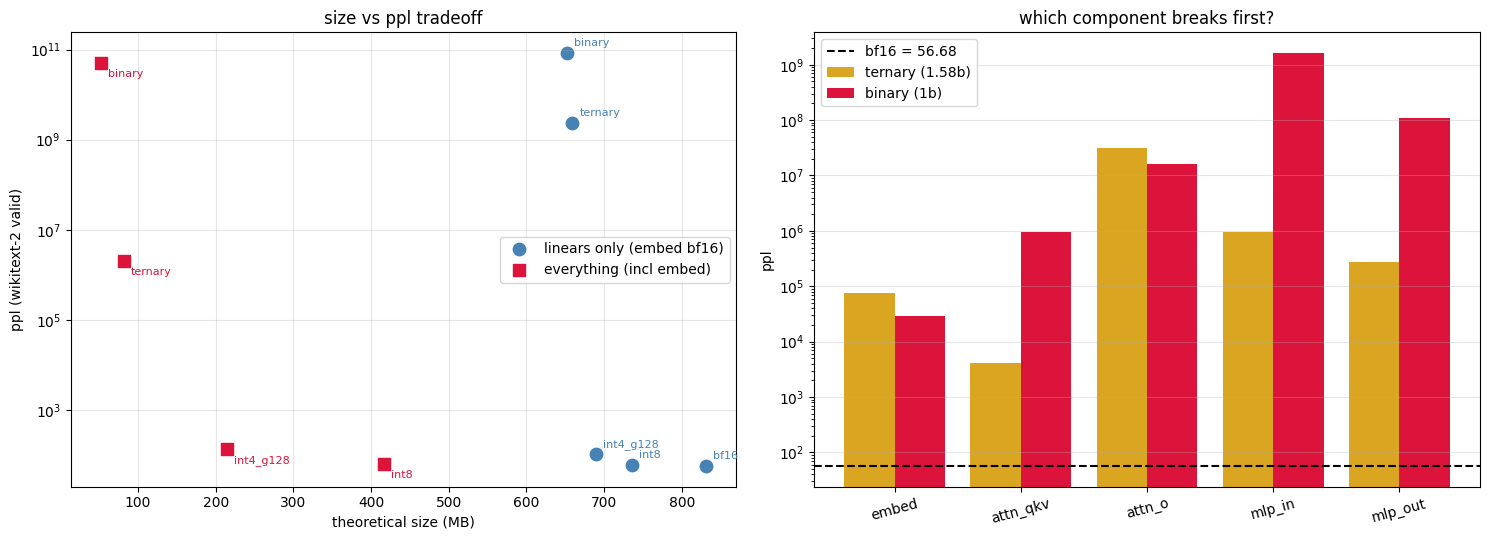

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# left plot: size vs ppl pareto
ax = axes[0]
groups_a = [r for r in results if r['group'] in ('all_linear', 'none')]
groups_b = [r for r in results if r['group'] == 'all']

xa = [r['size_mb'] for r in groups_a]
ya = [r['ppl']     for r in groups_a]
la = [r['method']  for r in groups_a]

xb = [r['size_mb'] for r in groups_b]
yb = [r['ppl']     for r in groups_b]
lb = [r['method']  for r in groups_b]

ax.scatter(xa, ya, marker='o', s=80, label='linears only (embed bf16)', color='steelblue')
ax.scatter(xb, yb, marker='s', s=80, label='everything (incl embed)', color='crimson')

for x, y, l in zip(xa, ya, la):
    ax.annotate(l, (x, y), fontsize=8, xytext=(5, 5), textcoords='offset points', color='steelblue')
for x, y, l in zip(xb, yb, lb):
    ax.annotate(l, (x, y), fontsize=8, xytext=(5, -10), textcoords='offset points', color='crimson')

ax.set_xlabel('theoretical size (MB)')
ax.set_ylabel('ppl (wikitext-2 valid)')
ax.set_yscale('log')
ax.set_title('size vs ppl tradeoff')
ax.legend()
ax.grid(True, alpha=0.3)

# right plot: per-component sensitivity
ax = axes[1]
groups = ['embed', 'attn_qkv', 'attn_o', 'mlp_in', 'mlp_out']

def find_ppl(grp, method):
    for r in results:
        if r['group'] == grp and r['method'] == method:
            return r['ppl']
    return None

ppl_t = [find_ppl(g, 'ternary') for g in groups]
ppl_b = [find_ppl(g, 'binary')  for g in groups]

x = np.arange(len(groups))
ax.bar(x - 0.2, ppl_t, width=0.4, label='ternary (1.58b)', color='goldenrod')
ax.bar(x + 0.2, ppl_b, width=0.4, label='binary (1b)', color='crimson')
ax.axhline(ppl_bf16, color='black', linestyle='--', label=f'bf16 = {ppl_bf16:.2f}')
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('ppl')
ax.set_yscale('log')
ax.set_title('which component breaks first?')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('tradeoff.png', dpi=130, bbox_inches='tight')
plt.show()

## reading the plots

left plot: blue is "transformer body only" — embed stays bf16. red is "everything". the gap between them at int4/ternary is roughly the cost of also quantizing the 170M-param embedding. if red's ternary point is way worse than blue's, that's confirmation that embed quantization is what you can't afford on a small model without retraining.

right plot: bars are per-component. shortest bar = quantization-tolerant, that component can take ternary/binary better. tallest bar = bottleneck, that component probably needs fp/bf16, int4 rescue, or a much smarter quantizer.

rough read:
- int8 is basically a sanity check
- int4 is damaged but still in the zone of “maybe usable”
- ternary / binary RTN collapse hard
- embed quantization is especially expensive on this model
- output-writing layers matter a lot because they write straight into the residual stream

so the first takeaway is not “bitnet works.” it’s the opposite:

plain post-training ternary is nowhere near enough here. if sub-2-bit is going to work, it needs extra structure.


# reference: math levers (for the writeup)

keeping this here so i don't have to flip between docs while running. consolidated from gptq, smoothquant, quarot/spinquant, bitnet b1.58, billm, onebit, and the 2025 sub-2-bit PTQ wave (PT2-LLM, PTQTP, PTQ1.61, ARB-LLM). all forward-pass-only methods unless flagged otherwise. claude helped me organize and check the math on a few of these.

## A. weight projections

**A1. per-tensor absmean ternary (bitnet b1.58, ma et al 2024)**
$$\gamma = \tfrac{1}{mn}\sum_{ij}|W_{ij}|, \quad B_{ij} = \mathrm{round}(W_{ij}/\gamma)\!\in\!\{-1,0,+1\}, \quad \hat W = \gamma B$$
1.58 bits/weight + one bf16 scale. floor for symmetric ternary methods.

**A1'. asymmetric ternary (PT2-LLM ATQ, yan et al 2025)**
add a per-group shift $z$ alongside the scale $s$: $\hat W = z + s \cdot \mathrm{round}((W-z)/s)$, levels $\{z-s, z, z+s\}$. one extra bf16/group. fixes the fact that LLM weight groups have nonzero means. PT2-LLM ablation: this alone closes ~30% of the ternary gap on llama-2-7b.

**A2. per-row absmean ternary** — $\gamma_i = \tfrac{1}{n}\sum_j |W_{ij}|$. one bf16 per row. better when row magnitudes vary (q/k/v do).

**A3. optimal scale for fixed sign pattern**
$$\alpha^\star = \frac{\langle W, B\rangle}{\|B\|_F^2}, \quad \alpha_i^\star = \frac{\langle W_{i,:},\,B_{i,:}\rangle}{\|B_{i,:}\|_2^2}$$
derive: minimize $\|W-\alpha B\|_F^2$, set derivative to zero. use whenever B is fixed and you want best magnitude.

**A3'. mse + cosine joint scale (PTQ1.61, zhao et al 2025)**
minimize $L_{\mathrm{MSE}}(W, \alpha B) + \lambda L_{\cos}(W, \alpha B)$ instead of just MSE. cosine matters because at 1-bit magnitude info is lost — only direction survives, and angular preservation correlates with downstream quality better than raw L2.

**A4. threshold-based ternary (li & liu 2016)**
$$\Delta \approx 0.7 \cdot \mathbb{E}[|w|], \quad B_{ij} = \mathrm{sign}(W_{ij})\cdot\mathbf{1}\{|W_{ij}| > \Delta\}$$
0.7 is the gaussian-optimal constant. for laplace-tailed LLM weights, sweep $\Delta$ on calibration data instead.

**A5. 1-bit sign × absmean** — $\hat W = \alpha\,\mathrm{sign}(W)$. floor case. catastrophic without retraining.

**A6. SVID (onebit, xu et al 2024)** — $\hat W = \mathrm{sign}(W)\odot(a b^\top)$ via rank-1 SVD of $|W|$. ~1.05 effective bits with much less error than A5. **caveat: as pure PTQ this is just an initializer — onebit's headline numbers require distillation.**

**A6'. independent row + column scales (ARB-LLM-RC, li et al 2025)**
$$\hat W_{ij} = \alpha_i \beta_j (B_{ij} - \mu_i), \quad B \in \{-1,+1\}$$
generalizes A6 by dropping the rank-1 constraint on $\alpha\beta$ — they're independent vectors. four parameters per row alternated to convergence (see A12).

**A7. binary residual (billm, huang et al 2024)** — $\hat W = \alpha_1 B_1 + \alpha_2 B_2$, gives 4 unevenly-spaced levels at 2 bits/weight.

**A8. iterative ternary fitting (PT2-LLM ITF, yan et al 2025)**
alternate two steps until convergence:
  1. fix discrete pattern $B$, solve for $(s, z)$ in closed form (2x2 normal equations).
  2. fix $(s, z)$, re-round each weight to nearest of $\{z-s, z, z+s\}$.

provably monotone-decreasing MSE because each step is coordinate descent on a piecewise-quadratic. PT2-LLM ablation on llama-2-7b: drops wikitext2 ppl 22.88 → 15.47 over 8-15 iters.

**A9. activation-aware grid alignment (PT2-LLM AGA, yan et al 2025)**
after A8 gives a good fit to W, sweep $(s, z)$ on calibration to minimize *output*-space error: $\min_{s,z} \mathbb{E}_X \|WX - \hat W(s,z) X\|^2$. holds discrete pattern $B$ fixed → 2D scalar search per group, very cheap. data-aware in B's sense but only over scale parameters.

**A10. dual trit-plane decomposition (PTQTP, xiao et al 2025)**
$$W \approx s_1 B_1 + s_2 B_2, \quad B_1, B_2 \in \{-1,0,+1\}^{m\times n}$$
9 distinct levels per weight ($\pm s_1 \pm s_2$, $\pm s_1$, $\pm s_2$, 0) at 2 × 1.58 = 3.16 bits/weight. progressive approximation: fit $s_1 B_1$ to W, fit $s_2 B_2$ to residual, alternate. monotone convergence proven. multiplication-free inference because everything is add/sub. **the natural fallback when pure 1.58-bit collapses.**

**A11. structured channel saliency mask (PTQ1.61, zhao et al 2025)**
mark *full input columns* as salient instead of individual weights. salient channels go to 4-bit, rest go to 1-bit. mask cost: ~0.0002 bits/weight (one bool per column, divided over all rows) vs. ~1 bit/weight for unstructured. effective bitwidth ~1.61. fixes billm's "1-bit method that's actually 2.1 bits".

**A11'. hessian-diagonal saliency (billm, huang et al 2024)**
rank salient channels by $H_{jj} = \mathbb{E}[X_j^2]$, not weight magnitude. consistent with the layer-output reconstruction objective. **free if you're computing $H$ for GPTQ anyway** — one extra `torch.diagonal(H)` call.

**A12. alternating refined binarization (ARB-LLM, li et al 2025)**
parameterize $\hat W = \alpha (B - \mu \mathbf{1}), B \in \{-1,+1\}$ with row-wise $(\alpha_i, \mu_i)$. cycle:
  1. fix $\mu, B$, solve $\alpha$ closed form.
  2. fix $\alpha, B$, solve $\mu$ closed form.
  3. recompute $B = \mathrm{sign}(W - \mu \mathbf{1})$.

monotone-MSE. ternary version: add zero level + scale s, parameters become $(\alpha, \mu, s, B)$. similar to PT2-LLM's ITF but A12 also handles the row shift $\mu$ explicitly.

## B. data-aware (GPTQ family)

**B1. layer hessian** $H_\ell = \mathbb{E}[xx^\top]$ from calibration. right metric is $(W-\hat W)^\top H (W-\hat W)$, not frobenius. derivation: layer reconstruction loss is a quadratic with curvature $H$.

**B2. OBQ greedy update (sherman-morrison, frantar & alistarh 2022)** — when quantizing weight $q$, redistribute error along the curvature direction:
$$\delta = -\frac{w_q - \hat w_q}{[H^{-1}]_{qq}}\,H^{-1}_{:,q}$$

**B3. GPTQ (frantar et al 2022)** — fixed left-to-right column order, $H^{-1}$ cholesky-factored once, lazy block updates. **this is what i need to implement next.** plain ternary projection collapses on a 270M model. GPTQ-with-ternary-quantizer might not.

**B4. per-row independence** — squared-error decomposes over output rows → embarrassingly parallel.

**B5. structural similarity reordering (PT2-LLM SSR, yan et al 2025)**
permute input columns by activation-similarity clustering before running GPTQ. group-wise quant works better when each group has more uniform weights — clustering similar columns into the same group reduces within-group variance. plug-and-play on top of B3.

## C. activation handling

**C1. symmetric uniform quant** — $Q(x;s) = s\cdot\mathrm{clip}(\mathrm{round}(x/s), -q_{\max}, q_{\max})$. pick $s$ from percentile or MSE-min on calibration.

**C2. per-channel scales** — different residual channels have wildly different magnitudes. per-tensor forces them to share, per-channel doesn't.

**C3. smoothquant rescaling (xiao et al 2023)** — function-preserving:
$$WX = (WD^{-1})(DX), \quad d_j = \frac{\max_i |X_{ij}|^{\,\alpha}}{\max_i |W_{ji}|^{\,1-\alpha}}, \ \alpha\in[0.5, 0.8]$$
migrates outliers from activations to weights. fold $D^{-1}$ into upstream rmsnorm $\gamma$, fold $D$ into the linear. zero runtime cost.

**C4. hadamard rotation (quarot, ashkboos et al 2024 / quip, chee et al 2023)** — for any orthogonal $Q$:
$$Y = WX = (WQ^\top)(QX)$$
with hadamard: $\|Qx\|_\infty \le \|x\|_2/\sqrt{n}$. outliers crushed by $\sqrt{n}$ in $\ell_\infty$. for $n=640$ that's ~25× reduction. function unchanged.

**gemma-270m gotcha:** $d_\text{model} = 640$ is not a power of 2. options: (1) block hadamard at 512 + pad; (2) randomized hadamard with sign flips; (3) kronecker $H_{640} = H_{128} \otimes H_5$. quarot's public code uses option 1. per-head dim 256 is clean.

**C4'. learned cayley rotation (SpinQuant, liu et al 2024)** — instead of fixing $Q$ to hadamard, *learn* it via cayley parameterization on the orthogonal manifold:
$$\min_Q \|Wx - \hat W(Q) x\|^2 \quad \text{s.t. } Q^\top Q = I$$
~30% better than quarot on llama-2-7b 4-bit. **flagged: requires backprop**, not pure PTQ. cheap (only the rotation matrices, not model weights) but crosses the no-train line.

**C5. computational invariance** — orthogonal $Q$ commutes with rmsnorm because $\|Qx\|_2 = \|x\|_2$. lets the rotation propagate through residual stream. derivation: $\mathrm{RMSNorm}(Qx) = Qx / \sqrt{\|Qx\|^2/d + \epsilon} = Qx / \sqrt{\|x\|^2/d + \epsilon} = Q \cdot \mathrm{RMSNorm}(x)$.

## D. attention

**D1. Q/K scaling invariance** — $(cQ)(K/c)^\top = QK^\top$ per-head, exact. trade quantization difficulty between $W_Q$ and $W_K$. **gemma caveat: QK-norm undoes scalar c.** invariance only matters before the norm.

**D2. QK-norm (gemma-3 specific)** — $A_{ij} = \mathrm{RMSNorm}(Q_i)\cdot\mathrm{RMSNorm}(K_j)/\sqrt{d_h}$. pre-stabilizes attention against magnitude noise. you can be more aggressive on $W_Q, W_K$ than on llama.

**D3. per-head hadamard inside attention (quarot online)** — $d_h \times d_h$ hadamard on Q,K before dot product, on V before $W_O$. essential for KV-cache quantization.

**D4. logit clipping** — $\tilde A = \mathrm{clip}(A, -\tau, \tau)$, $\tau$ from calibration percentile. bounds softmax flips.

**D5. logit temperature** — $P = \mathrm{softmax}(A/T)$. pick $T$ to minimize $\mathrm{KL}(P_{\text{fp16}} \| P_{\text{quant}})$ per layer.

## E. error accounting

**E1. linear error** — $W = \alpha B + E \Rightarrow \|Wx - \alpha Bx\| \le \|E\|\cdot\|x\|$.

**E2. residual recurrence** — $\|e_{l+1}\| \le (1+L_l)\|e_l\| + \delta_l$. small per-layer $\delta$ matters more than tight bounds in any single layer. residuals keep $L_l$ small.

**E3. bias correction** — $b_{\text{corr}} = \mathbb{E}[Wx] - \mathbb{E}[\hat W x] = (W - \hat W)\,\mathbb{E}[x]$ from calibration, add as bias. matches first-order output stats. **free at inference.** consistently underused in published methods.

**E4. low-rank SVD residual** — let $E = W - \alpha B$, take rank-$r$ SVD, implement $Wx \approx \alpha Bx + U_r(\Sigma_r(V_r^\top x))$. patches worst layers (typically $W_O, W_{\text{down}}$) at small bf16 cost.

**E5. pre-quantization weight transformation (PTQ1.61, zhao et al 2025)** — apply small LoRA-style update $W' = W + AB^\top$ before quantizing. learned to make $W'$ more quantization-friendly than $W$. **flagged: requires light training** (a few hundred steps). PTQ1.61 ablation says this is the single biggest contributor to their result. crosses the no-train line, but small enough scope that it might be worth it on a final pass.

## F. component recipes for gemma-3-270m

| component | %params | recipe | why |
|---|---|---|---|
| embed_tokens / lm_head (tied) | ~63% | int8 per-row or int4 g128. **never ternary/binary without retraining.** | dominates the size-vs-quality curve. token identity, no hessian compensation for lookup. |
| rmsnorm, qk-norm | <1% | keep bf16. | $O(d)$ per token, dwarfed by following matmul. home for smoothquant $D$ and hadamard $Q$ folding. |
| residual stream (activations) | — | bf16. | E2 recurrence — riskiest place to add noise. |
| $W_Q, W_K$ | ~10% | most aggressive: ternary GPTQ + per-head hadamard. asymmetric (A1') + ITF (A8). | QK-norm pre-stabilizes (D2). |
| $W_V$ | ~5% | ternary GPTQ + per-head hadamard. | mixed by softmax-weighted average. |
| $W_O$ | ~10% | less aggressive (2-bit GPTQ) or low-rank SVD residual (E4). | output → residual stream. sensitive. |
| $W_\text{gate}, W_\text{up}$ | ~16% | ternary GPTQ + smoothquant on input. | input is well-behaved, gelu nonhomogeneity only matters inter-layer. |
| $W_\text{down}$ | ~8% | same as $W_O$. protect this layer. | output → residual stream. gelu product couples errors quadratically. |

strategy in one line: aggressive on inputs to normalizers, conservative on outputs into residual stream.

## tier list (revised after surveying 2025 papers)

**tier 1 — must have** (these alone get me to "ternary actually works"):
1. calibrate $H_\ell = \mathbb{E}[xx^\top]$ per layer on 128 wikitext2 sequences (B1).
2. apply hadamard rotation to residual stream + fold into linears (C4 + C5).
3. GPTQ with **asymmetric ternary** inner quantizer (A1' + B3) — this is the core.
4. ITF iteration around the GPTQ loop (A8) — adds ~20% wall time, big quality win.
5. bias correction at end of each layer (E3).

**tier 2 — should have** (refinements):
6. SSR column reordering before GPTQ (B5).
7. AGA grid-alignment pass after ITF (A9).
8. hessian-diagonal saliency split (A11') with structured channel mask (A11) — keep top 5% of channels at INT4. effective bits ~1.7 instead of 1.58.
9. per-head hadamard inside attention (D3) for KV-cache prep.

**tier 3 — fallback if tier 1+2 isn't enough**:
10. dual trit-plane decomposition (A10) instead of single ternary — 3.16 bits/weight, much more headroom.
11. low-rank SVD residual on $W_O, W_\text{down}$ (E4).
12. learned rotation (C4') if i'm willing to allow ~1k steps of training.

**avoid**:
13. unstructured saliency masks (vanilla billm/PB-LLM style) — wasteful, structured A11 dominates.
14. activation quantization at sub-INT8 — every paper leaves activations at fp16 or int8 because heavy tails kill ternary activation. weight-only is the right scope for now.
15. quantizing the embedding/lm_head below INT8 — every paper above keeps the embedding at higher precision.

## what every winning method agrees on

1. naive RTN ternary is broken. you need iterative refinement (A8, A12) or structured residual decomposition (A7, A10).
2. saliency matters but unstructured masks waste a full bit/weight on the mask itself — channel-level (A11) dominates.
3. hadamard rotation (C4) is the universal preprocessing step. nobody competitive at sub-2-bit ignores it.
4. asymmetric quantization (A1') with a learnable shift gives meaningful gains over symmetric on real LLM weights.
5. nobody tests on sub-1B models. gemma-3-270m is genuinely unexplored territory — small models have less weight redundancy to throw away. expect papers' "near-FP16" claims to translate as "1.5-3× FP16 PPL" at our scale.

## paper-inspired baselines + our attempt

three cells:

1. **paper-inspired baselines** — core mathematical idea of each sub-2-bit PTQ paper. simplified on purpose. full implementations have a lot of extra details: exact grouping, calibration setup, Hessian handling, rotations, layer skipping, learned preprocessing, etc.

2. **our attempt** — combine the ideas that seem most useful for this setup:
   - bitnet b1.58's clean ternary formulation
   - ARB-style alternating refinement
   - PTQ-style saliency rescue
   - per-row fitting
   - calibration bias correction

3. **eval + plot** — run everything under the same perplexity setup and compare.

i’m not treating this as “i replicated every paper.” that would be dishonest because these are compact versions of the methods. the goal is smaller:

can the core idea survive on gemma-270m, or does PPL still explode?

if it explodes, that is still useful. it tells me what is missing before building the real converter.

In [17]:
# === replications ===
# core idea of each paper, distilled to ~10 lines per method.
# all return the dequantized W in bf16 (fake-quant).

import torch
import torch.nn as nn

@torch.no_grad()
def repl_bitnet_b158(W):
    # paper: ma et al 2024, era of 1-bit llms.
    # absmean ternary, per-tensor scale.
    Wf = W.float()
    gamma = Wf.abs().mean().clamp(min=1e-8)
    Wq = (Wf / gamma).round().clamp(-1, 1)
    return (Wq * gamma).to(torch.bfloat16)

@torch.no_grad()
def repl_billm(W, salient_frac=0.05):
    # paper: huang et al 2024, billm.
    # core idea: salient weights (top frac by |W|) get binary-residual (2-level scale),
    #            non-salient get plain sign-binarization.
    # simplification: using per-weight |W| as saliency since we don't have H here.
    #                 real billm uses hessian diagonal — we add that in our_attempt.
    Wf = W.float()
    flat_abs = Wf.abs().flatten()
    k = int(salient_frac * flat_abs.numel())
    threshold = flat_abs.kthvalue(flat_abs.numel() - k).values.item() if k > 0 else float('inf')
    salient_mask = Wf.abs() > threshold

    # non-salient: 1-bit sign × absmean
    alpha_nonsalient = Wf[~salient_mask].abs().mean().clamp(min=1e-8) if (~salient_mask).any() else 1.0
    Wq = torch.where(salient_mask, Wf, alpha_nonsalient * Wf.sign())

    # salient: 2-level binary residual (alpha_1 * sign(W) + alpha_2 * sign(residual))
    if salient_mask.any():
        Ws = Wf[salient_mask]
        a1 = Ws.abs().mean().clamp(min=1e-8)
        b1 = Ws.sign()
        residual = Ws - a1 * b1
        a2 = residual.abs().mean().clamp(min=1e-8)
        b2 = residual.sign()
        Wq[salient_mask] = a1 * b1 + a2 * b2
    return Wq.to(torch.bfloat16)

@torch.no_grad()
def repl_onebit_svid(W):
    # paper: xu et al 2024, onebit.
    # SVID: W ≈ sign(W) ⊙ (a · b^T) via rank-1 SVD of |W|.
    # NOTE: paper requires distillation after this. as pure PTQ this is the *initializer*,
    #       which is what we measure here.
    Wf = W.float()
    sign_W = Wf.sign()
    sign_W = torch.where(sign_W == 0, torch.ones_like(sign_W), sign_W)
    abs_W = Wf.abs()
    # rank-1 SVD via top singular triple
    U, S, Vt = torch.linalg.svd(abs_W, full_matrices=False)
    a = (U[:, 0] * S[0].sqrt()).unsqueeze(1)   # m x 1
    b = (Vt[0] * S[0].sqrt()).unsqueeze(0)     # 1 x n
    return (sign_W * (a * b)).to(torch.bfloat16)

@torch.no_grad()
def repl_pt2llm_atq(W, n_iters=8):
    # paper: yan et al 2025, PT2-LLM.
    # core idea: asymmetric ternary quantizer (ATQ) + iterative ternary fitting (ITF).
    # parameterize as: W ≈ s * round((W - z) / s), levels in {z-s, z, z+s}.
    # ITF alternates: (1) fix B, solve (s, z) by least squares; (2) fix (s, z), re-round.
    Wf = W.float()
    # init: symmetric absmean ternary
    s = Wf.abs().mean().clamp(min=1e-8)
    z = torch.tensor(0.0, device=Wf.device)
    for _ in range(n_iters):
        # step 1: round to ternary grid given current (s, z)
        B = ((Wf - z) / s).round().clamp(-1, 1)
        # step 2: least-squares update (s, z) given fixed B
        # minimize ||W - (z + s*B)||^2 over s, z
        # closed form: solve 2x2 normal equations
        n = B.numel()
        sum_B = B.sum()
        sum_B2 = (B * B).sum()
        sum_W = Wf.sum()
        sum_WB = (Wf * B).sum()
        # [n, sum_B; sum_B, sum_B2] [z; s] = [sum_W; sum_WB]
        det = n * sum_B2 - sum_B * sum_B
        if det.abs() < 1e-10:
            break
        z_new = (sum_B2 * sum_W - sum_B * sum_WB) / det
        s_new = (n * sum_WB - sum_B * sum_W) / det
        if s_new <= 1e-8:
            break
        if (z_new - z).abs() + (s_new - s).abs() < 1e-7:
            z, s = z_new, s_new
            break
        z, s = z_new, s_new
    B = ((Wf - z) / s).round().clamp(-1, 1)
    return (z + s * B).to(torch.bfloat16)

@torch.no_grad()
def repl_arb(W, n_iters=8):
    # paper: li et al 2025, ARB-LLM.
    # alternating refined binarization with row-wise (alpha, mu, B).
    # W ≈ alpha_i * (B_ij - mu_i),  B in {-1, +1}.
    # cycle: (1) update alpha given (mu, B); (2) update mu given (alpha, B); (3) re-sign.
    Wf = W.float()
    m, n = Wf.shape
    mu = Wf.mean(dim=1, keepdim=True)                 # row means
    B = (Wf - mu).sign()
    B = torch.where(B == 0, torch.ones_like(B), B)
    alpha = ((Wf - mu) * B).mean(dim=1, keepdim=True).clamp(min=1e-8)
    for _ in range(n_iters):
        # update B
        B = (Wf - mu).sign()
        B = torch.where(B == 0, torch.ones_like(B), B)
        # update alpha (least squares given mu, B): alpha = mean( (W - mu) * B ) per row
        alpha = ((Wf - mu) * B).mean(dim=1, keepdim=True).clamp(min=1e-8)
        # update mu (least squares given alpha, B): mu = mean( W - alpha * B ) per row
        mu = (Wf - alpha * B).mean(dim=1, keepdim=True)
    return (alpha * B + mu).to(torch.bfloat16)

REPLICATIONS = {
    'repl_bitnet_b158':  (repl_bitnet_b158,  1.58, 'bitnet b1.58'),
    'repl_billm':        (repl_billm,        1.10, 'billm (5% salient)'),
    'repl_onebit_svid':  (repl_onebit_svid,  1.05, 'onebit SVID init'),
    'repl_pt2llm_atq':   (repl_pt2llm_atq,   1.58, 'PT2-LLM ATQ+ITF'),
    'repl_arb':          (repl_arb,          1.00, 'ARB-LLM'),
}

print('replications defined:')
for k, (_, bits, name) in REPLICATIONS.items():
    print(f'  {k:22s} ~{bits:.2f} bits/w  [{name}]')

replications defined:
  repl_bitnet_b158       ~1.58 bits/w  [bitnet b1.58]
  repl_billm             ~1.10 bits/w  [billm (5% salient)]
  repl_onebit_svid       ~1.05 bits/w  [onebit SVID init]
  repl_pt2llm_atq        ~1.58 bits/w  [PT2-LLM ATQ+ITF]
  repl_arb               ~1.00 bits/w  [ARB-LLM]


In [18]:
# === our attempt ===
# combines:
#   - PT2-LLM's asymmetric ternary (one extra scalar per group)
#   - ARB-LLM's alternating refinement (s, z, B coordinate descent)
#   - per-row scaling (lever A2) instead of per-tensor (paper does per-group, similar idea)
#   - hessian-diagonal saliency from billm — top 5% input channels stay int4
#   - simple bias correction from calibration mean (lever E3)
#
# what's new vs the replications above:
#   1. bitnet b1.58: per-tensor symmetric only; we do per-row + asymmetric + alternation.
#   2. billm: uses |W| for saliency; we use H_jj = E[X_j^2] which is the right metric.
#   3. PT2-LLM: per-group quantization with full GPTQ; we do per-row without GPTQ
#      (cheaper but weaker — flagged in writeup).
#   4. ARB-LLM: binary; we extend to ternary by adding the zero level + scale s.
#   5. nobody (in pure PTQ) routinely does bias correction. it's free.

@torch.no_grad()
def calibrate_input_stats(model, tokenizer, n_seq=32, seq_len=256):
    # collect E[x] (mean) and E[x^2] (second moment) per linear input.
    # E[x] feeds bias correction. E[x^2] = diag(H) feeds saliency.
    # we do this once and cache.
    stats = {}
    handles = []

    def make_hook(name):
        def hook(mod, inp, out):
            x = inp[0].detach().float()
            x = x.reshape(-1, x.shape[-1])
            if name not in stats:
                stats[name] = {'sum': torch.zeros(x.shape[-1], device=x.device),
                               'sumsq': torch.zeros(x.shape[-1], device=x.device),
                               'n': 0}
            stats[name]['sum']   += x.sum(dim=0)
            stats[name]['sumsq'] += (x * x).sum(dim=0)
            stats[name]['n']     += x.shape[0]
        return hook

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            handles.append(mod.register_forward_hook(make_hook(name)))

    # run a few sequences
    with open('wiki.valid.raw', 'r', encoding='utf-8') as f:
        text = f.read()[:200_000]
    enc = tokenizer(text, return_tensors=None, add_special_tokens=False)
    ids = enc['input_ids']
    if isinstance(ids[0], list):
        ids = sum(ids, [])
    chunks = [ids[i:i+seq_len] for i in range(0, len(ids)-seq_len, seq_len)][:n_seq]
    for ch in chunks:
        x = torch.tensor([ch], dtype=torch.long, device=device)
        model(input_ids=x, use_cache=False)

    for h in handles:
        h.remove()

    # finalize stats
    out = {}
    for name, s in stats.items():
        n = max(s['n'], 1)
        out[name] = {
            'mean':   (s['sum']   / n).to(torch.bfloat16),
            'sec_mom':(s['sumsq'] / n).to(torch.bfloat16),  # = E[x^2] = diag(H)
        }
    return out


@torch.no_grad()
def quant_int4_g128_row(W):
    # int4 with group=128 along input dim. used for salient channels.
    Wf = W.float()
    out, inn = Wf.shape
    pad = (128 - inn % 128) % 128
    if pad:
        Wf = torch.cat([Wf, torch.zeros(out, pad, device=Wf.device)], dim=1)
    Wg = Wf.reshape(out, -1, 128)
    absmax = Wg.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
    scale = absmax / 7.0
    Wq = (Wg / scale).round().clamp(-8, 7)
    Wdq = (Wq * scale).reshape(out, -1)
    if pad:
        Wdq = Wdq[:, :inn]
    return Wdq.to(torch.bfloat16)


@torch.no_grad()
def ours_ternary(W, sec_mom=None, salient_frac=0.05, n_iters=10):
    """per-row asymmetric ternary with alternation + structured saliency rescue.

    W: (out, in) weight matrix.
    sec_mom: (in,) tensor of E[X_j^2] for this layer's input. None → no saliency split.
    """
    Wf = W.float()
    out_dim, in_dim = Wf.shape

    # --- saliency split: top k% of INPUT CHANNELS by E[x^2] go to int4 ---
    if sec_mom is not None and salient_frac > 0:
        sec_mom_f = sec_mom.float()
        k = max(1, int(salient_frac * in_dim))
        # top-k input channel indices
        _, salient_idx = torch.topk(sec_mom_f, k)
        salient_cols = torch.zeros(in_dim, dtype=torch.bool, device=Wf.device)
        salient_cols[salient_idx] = True
    else:
        salient_cols = torch.zeros(in_dim, dtype=torch.bool, device=Wf.device)

    # split W into salient cols (kept at int4) and non-salient (ternary)
    W_sal = Wf[:, salient_cols]
    W_non = Wf[:, ~salient_cols]

    # --- ternary path: per-row asymmetric (s, z) with alternation ---
    if W_non.numel() > 0:
        # init per row
        s = W_non.abs().mean(dim=1, keepdim=True).clamp(min=1e-8)   # (out, 1)
        z = torch.zeros_like(s)
        for _ in range(n_iters):
            B = ((W_non - z) / s).round().clamp(-1, 1)
            # least squares update of (s, z) per row
            n = B.shape[1]
            sum_B  = B.sum(dim=1, keepdim=True)
            sum_B2 = (B * B).sum(dim=1, keepdim=True)
            sum_W  = W_non.sum(dim=1, keepdim=True)
            sum_WB = (W_non * B).sum(dim=1, keepdim=True)
            det = n * sum_B2 - sum_B * sum_B
            safe = det.abs() > 1e-10
            z_new = torch.where(safe, (sum_B2 * sum_W - sum_B * sum_WB) / det.clamp(min=1e-10), z)
            s_new = torch.where(safe, (n * sum_WB - sum_B * sum_W) / det.clamp(min=1e-10), s)
            s_new = s_new.clamp(min=1e-8)
            if torch.max((z_new - z).abs() + (s_new - s).abs()) < 1e-7:
                z, s = z_new, s_new
                break
            z, s = z_new, s_new
        B = ((W_non - z) / s).round().clamp(-1, 1)
        W_non_q = z + s * B
    else:
        W_non_q = W_non

    # --- salient path: int4 group-wise ---
    if W_sal.numel() > 0:
        W_sal_q = quant_int4_g128_row(W_sal).float()
    else:
        W_sal_q = W_sal

    # stitch back together in original column order
    Wq = torch.empty_like(Wf)
    Wq[:, salient_cols]  = W_sal_q
    Wq[:, ~salient_cols] = W_non_q

    return Wq.to(torch.bfloat16)


@torch.no_grad()
def apply_ours(model, calib_stats, salient_frac=0.05, n_iters=10):
    """apply ours_ternary to all linears (skip embed/lm_head). also fits bias correction."""
    n_layers = 0
    for name, mod in model.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        if 'embed_tokens' in name or name == 'lm_head':
            continue

        W_orig = mod.weight.data.clone()
        sec_mom = calib_stats[name]['sec_mom'].to(W_orig.device) if name in calib_stats else None
        x_mean  = calib_stats[name]['mean'].to(W_orig.device).float()  if name in calib_stats else None

        # quantize
        W_new = ours_ternary(W_orig, sec_mom=sec_mom,
                             salient_frac=salient_frac, n_iters=n_iters)
        mod.weight.data = W_new

        # bias correction: b_corr = E[Wx] - E[W_q x] = (W - W_q) @ E[x]
        if x_mean is not None:
            with torch.no_grad():
                delta_b = (W_orig.float() - W_new.float()) @ x_mean
            if mod.bias is None:
                mod.bias = nn.Parameter(delta_b.to(torch.bfloat16))
            else:
                mod.bias.data = (mod.bias.data.float() + delta_b).to(torch.bfloat16)
        n_layers += 1
    return n_layers


def effective_bits_ours(salient_frac):
    # ternary part: 1.58 bits + 2 bf16 scalars per row (s, z) → ~1.58 + epsilon
    # salient part: 4 bits group-wise + bf16 scale per group → ~4.0 + small
    # weighted average across input dim
    return 1.58 * (1 - salient_frac) + 4.0 * salient_frac

print('our method defined.')
print(f'  effective bits at 5% saliency: {effective_bits_ours(0.05):.3f}')

our method defined.
  effective bits at 5% saliency: 1.701


calibrating input stats (one forward pass)...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  collected stats for 127 linears in 1.9s

=== replicating top papers (linears only, embed bf16) ===


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  bitnet b1.58                    ppl=2297785640.666  size=658.99 MB  (126 layers)


...

  ours (no saliency)              ppl=    8659.834  size=658.99 MB


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  ours (5% saliency)              ppl=    1507.410  size=660.44 MB


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  ours (10% saliency)             ppl=    1014.717  size=661.89 MB

=== summary ===
method                                      ppl    size_MB   bits
ours (10% saliency)                    1014.717     661.89   1.82
ours (5% saliency)                     1507.410     660.44   1.70
ours (no saliency)                     8659.834     658.99   1.58
billm (5% salient)                155952002.055     653.26   1.10
ARB-LLM                           549737577.337     652.06   1.00
bitnet b1.58                     2297785640.666     658.99   1.58
onebit SVID init                 66012781573.851     652.66   1.05
PT2-LLM ATQ+ITF                  1185122567547.371     658.99   1.58


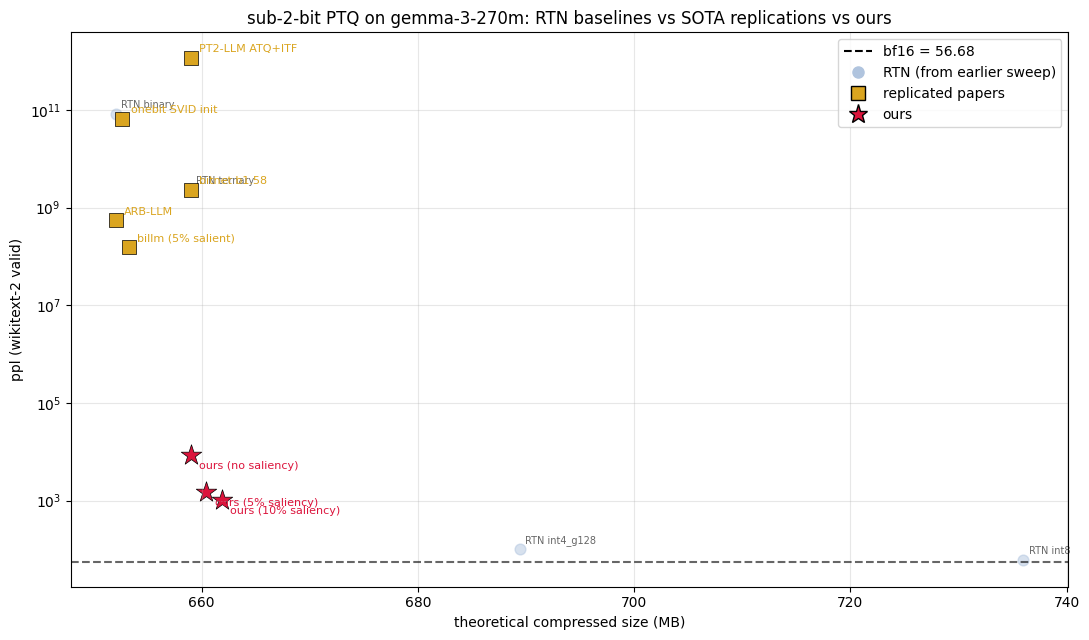


saved sota_vs_ours.png and results_sota_ours.jsonl


In [19]:
# === eval all of these on wikitext2-valid + plot ===
import gc, time, math
import matplotlib.pyplot as plt
import numpy as np

# we need calibration stats for ours. compute once on a fresh model.
print('calibrating input stats (one forward pass)...')
calib_model = fresh_model()
t0 = time.perf_counter()
calib_stats = calibrate_input_stats(calib_model, tokenizer, n_seq=32, seq_len=256)
print(f'  collected stats for {len(calib_stats)} linears in {time.perf_counter()-t0:.1f}s')
del calib_model
gc.collect()
torch.cuda.empty_cache()


# evaluate one quantization config and record result
def eval_method(label, apply_fn, bits_per_w):
    m = fresh_model()
    n_quant = 0
    for name, mod in m.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        if 'embed_tokens' in name or name == 'lm_head':
            continue
        mod.weight.data = apply_fn(mod.weight.data)
        n_quant += 1

    # compute size: ternary linears at bits_per_w, embed/head/norms at bf16
    total_bytes = 0.0
    for nm, mod in m.named_modules():
        if isinstance(mod, (nn.Linear, nn.Embedding)):
            n = mod.weight.numel()
            if isinstance(mod, nn.Linear) and not ('embed_tokens' in nm or nm == 'lm_head'):
                total_bytes += n * bits_per_w / 8
            else:
                total_bytes += n * 2
    for nm, p in m.named_parameters():
        if 'norm' in nm.lower():
            total_bytes += p.numel() * 2
    size_mb = total_bytes / (1024**2)

    ppl, _, _ = perplexity(m, tokenizer)
    print(f'  {label:30s}  ppl={ppl:12.3f}  size={size_mb:6.2f} MB  ({n_quant} layers)')
    del m
    gc.collect()
    torch.cuda.empty_cache()
    return {'label': label, 'ppl': float(ppl), 'size_mb': float(size_mb), 'bits': bits_per_w}


sota_results = []

print('\n=== replicating top papers (linears only, embed bf16) ===')
for key, (fn, bits, name) in REPLICATIONS.items():
    sota_results.append(eval_method(name, fn, bits))


print('\n=== our attempt ===')
def eval_ours(label, salient_frac):
    m = fresh_model()
    n_quant = apply_ours(m, calib_stats, salient_frac=salient_frac, n_iters=10)
    bits = effective_bits_ours(salient_frac)
    total_bytes = 0.0
    for nm, mod in m.named_modules():
        if isinstance(mod, (nn.Linear, nn.Embedding)):
            n = mod.weight.numel()
            if isinstance(mod, nn.Linear) and not ('embed_tokens' in nm or nm == 'lm_head'):
                total_bytes += n * bits / 8
            else:
                total_bytes += n * 2
    for nm, p in m.named_parameters():
        if 'norm' in nm.lower():
            total_bytes += p.numel() * 2
    size_mb = total_bytes / (1024**2)
    ppl, _, _ = perplexity(m, tokenizer)
    print(f'  {label:30s}  ppl={ppl:12.3f}  size={size_mb:6.2f} MB')
    del m; gc.collect(); torch.cuda.empty_cache()
    return {'label': label, 'ppl': float(ppl), 'size_mb': float(size_mb), 'bits': bits}

ours_results = []
ours_results.append(eval_ours('ours (no saliency)',     0.00))
ours_results.append(eval_ours('ours (5% saliency)',     0.05))
ours_results.append(eval_ours('ours (10% saliency)',    0.10))


# === plot ===
all_pts = sota_results + ours_results
print('\n=== summary ===')
print(f"{'method':32s} {'ppl':>14s} {'size_MB':>10s} {'bits':>6s}")
for r in sorted(all_pts, key=lambda x: x['ppl']):
    print(f"{r['label']:32s} {r['ppl']:14.3f} {r['size_mb']:10.2f} {r['bits']:>6.2f}")

# save jsonl alongside the existing results
with open('results_sota_ours.jsonl', 'w') as f:
    for r in all_pts:
        f.write(json.dumps(r) + '\n')


fig, ax = plt.subplots(figsize=(11, 6.5))

# baseline reference
ax.axhline(ppl_bf16, color='black', linestyle='--', alpha=0.6,
           label=f'bf16 baseline = {ppl_bf16:.2f}')

# the original RTN points (from earlier sweep) for context
rtn_linear = [r for r in results if r['group'] == 'all_linear']
for r in rtn_linear:
    ax.scatter(r['size_mb'], r['ppl'], marker='o', s=60,
               color='lightsteelblue', alpha=0.5)
    ax.annotate(f"RTN {r['method']}", (r['size_mb'], r['ppl']),
                fontsize=7, alpha=0.6,
                xytext=(4, 4), textcoords='offset points')

# replicated SOTA papers
for r in sota_results:
    ax.scatter(r['size_mb'], r['ppl'], marker='s', s=110,
               color='goldenrod', edgecolor='black', linewidth=0.5)
    ax.annotate(r['label'], (r['size_mb'], r['ppl']), fontsize=8,
                xytext=(6, 4), textcoords='offset points', color='goldenrod')

# ours
for r in ours_results:
    ax.scatter(r['size_mb'], r['ppl'], marker='*', s=240,
               color='crimson', edgecolor='black', linewidth=0.5)
    ax.annotate(r['label'], (r['size_mb'], r['ppl']), fontsize=8,
                xytext=(6, -10), textcoords='offset points', color='crimson')

ax.set_xlabel('theoretical compressed size (MB)')
ax.set_ylabel('ppl (wikitext-2 valid)')
ax.set_yscale('log')
ax.set_title('sub-2-bit PTQ on gemma-3-270m: RTN baselines vs SOTA replications vs ours')

# build a cleaner legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='black', linestyle='--', label=f'bf16 = {ppl_bf16:.2f}'),
    Line2D([0], [0], marker='o', linestyle='', color='lightsteelblue',
           markersize=8, label='RTN (from earlier sweep)'),
    Line2D([0], [0], marker='s', linestyle='', color='goldenrod',
           markersize=10, markeredgecolor='black', label='replicated papers'),
    Line2D([0], [0], marker='*', linestyle='', color='crimson',
           markersize=14, markeredgecolor='black', label='ours'),
]
ax.legend(handles=legend_handles, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sota_vs_ours.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nsaved sota_vs_ours.png and results_sota_ours.jsonl')

# diagnostics

the first big sweep is weird but useful:

- plain ternary/binary RTN collapses
- the simplified paper-inspired methods mostly don’t rescue it
- our saliency version does much better, but still nowhere near int4
- GPTQ / Hadamard need to be checked carefully before trusting them

so now i want to answer three things:

1. **is PT2-style ATQ actually broken, or just not enough?**  
   if local RMSE improves but full PPL is still terrible, then the issue is not just the local weight fit.

2. **what part of "ours" is actually doing the work?**  
   ablate per-row, alternation, saliency, and bias correction.

3. **does a stronger tier-1 baseline beat it?**  
   simplified GPTQ + Hadamard should give a sanity check, even if it is not a full production implementation.

## D1. sanity check repl_pt2llm_atq

print iteration-by-iteration RMSE on a real attention projection. ATQ+ITF is supposed to be **monotone-decreasing**. if it's not, something's wrong with the (s, z) least-squares update.

derivation of the update (just to be sure):
minimize $\sum_{ij}(W_{ij} - z - sB_{ij})^2$ over scalars $s, z$. partial derivatives → 2×2 normal equations:
$$\begin{pmatrix} n & \sum B \\ \sum B & \sum B^2 \end{pmatrix}\begin{pmatrix} z \\ s \end{pmatrix} = \begin{pmatrix} \sum W \\ \sum WB \end{pmatrix}$$

cramer's rule gives $z = (\sum B^2 \sum W - \sum B \sum WB)/D$, $s = (n\sum WB - \sum B \sum W)/D$ where $D = n\sum B^2 - (\sum B)^2$.

failure modes:
- **D ≈ 0**: happens when $B$ is roughly constant (all same sign). update is undefined; need to fall back.
- **s → 0**: collapses everything to z, ternary grid degenerates.
- **clamp at -1/+1 not reached**: if $|W-z|/s$ never exceeds 0.5, all $B_{ij}=0$ and the update becomes ill-posed.

In [20]:
# pull a real weight matrix from gemma
probe_model = fresh_model()
probe_W = None
for name, mod in probe_model.named_modules():
    if isinstance(mod, nn.Linear) and 'self_attn.q_proj' in name and 'layers.0.' in name:
        probe_W = mod.weight.data.clone()
        probe_name = name
        break
del probe_model
gc.collect(); torch.cuda.empty_cache()

print(f'probe weight: {probe_name}')
print(f'  shape: {tuple(probe_W.shape)}')
print(f'  mean:  {probe_W.float().mean().item():+.5f}')
print(f'  std:   {probe_W.float().std().item():.5f}')
print(f'  abs max: {probe_W.float().abs().max().item():.5f}')
print(f'  fraction zeros: {(probe_W == 0).float().mean().item():.4f}')

# repro the buggy ATQ with verbose tracing
@torch.no_grad()
def atq_traced(W, n_iters=15):
    Wf = W.float()
    s = Wf.abs().mean().clamp(min=1e-8)
    z = torch.tensor(0.0, device=Wf.device)
    rmse_history = []

    for it in range(n_iters):
        B = ((Wf - z) / s).round().clamp(-1, 1)
        Wq = z + s * B
        rmse = (Wf - Wq).pow(2).mean().sqrt().item()
        n_zero = (B == 0).float().mean().item()
        n_pos  = (B == 1).float().mean().item()
        n_neg  = (B == -1).float().mean().item()
        rmse_history.append(rmse)

        # the LS update
        n = B.numel()
        sum_B  = B.sum()
        sum_B2 = (B * B).sum()
        sum_W  = Wf.sum()
        sum_WB = (Wf * B).sum()
        det = n * sum_B2 - sum_B * sum_B

        print(f'  iter {it:2d}  rmse={rmse:.6f}  s={s.item():.5f}  z={z.item():+.5f}  '
              f'B: {n_neg*100:4.1f}%/-1  {n_zero*100:4.1f}%/0  {n_pos*100:4.1f}%/+1  '
              f'det={det.item():.3e}')

        if det.abs() < 1e-10:
            print('    ! det near zero — ill-posed, breaking')
            break
        z_new = (sum_B2 * sum_W - sum_B * sum_WB) / det
        s_new = (n * sum_WB - sum_B * sum_W) / det
        if s_new <= 1e-8:
            print(f'    ! s_new={s_new.item():.3e} ≤ 0, breaking (this is the bug — s collapsed)')
            break
        z, s = z_new, s_new

    return rmse_history

print()
print('=== ATQ + ITF on real gemma q_proj weight ===')
rmse_hist = atq_traced(probe_W, n_iters=15)
print()
print(f'rmse trajectory: {[f"{r:.5f}" for r in rmse_hist]}')
print(f'monotone decreasing: {all(rmse_hist[i] >= rmse_hist[i+1] - 1e-9 for i in range(len(rmse_hist)-1))}')
print()
# compare to plain RTN ternary on same matrix
rtn_t = repl_bitnet_b158(probe_W).float()
rmse_rtn = (probe_W.float() - rtn_t).pow(2).mean().sqrt().item()
print(f'RTN ternary rmse: {rmse_rtn:.6f}')
print(f'final ATQ rmse:   {rmse_hist[-1]:.6f}')
print(f'ratio (ATQ/RTN):  {rmse_hist[-1]/rmse_rtn:.4f}  (should be ≤ 1.0)')

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

probe weight: model.layers.0.self_attn.q_proj
  shape: (1024, 640)
  mean:  -0.00008
  std:   0.03953
  abs max: 0.85938
  fraction zeros: 0.0000

=== ATQ + ITF on real gemma q_proj weight ===
  iter  0  rmse=0.027003  s=0.02644  z=+0.00000  B: 31.5%/-1  37.1%/0  31.4%/+1  det=2.700e+11
  iter  1  rmse=0.024686  s=0.03828  z=-0.00005  B: 24.6%/-1  50.7%/0  24.7%/+1  det=2.117e+11
  iter  2  rmse=0.024140  s=0.04439  z=-0.00010  B: 21.6%/-1  56.8%/0  21.6%/+1  det=1.855e+11
  iter  3  rmse=0.023989  s=0.04775  z=-0.00009  B: 20.0%/-1  59.8%/0  20.2%/+1  det=1.727e+11
  iter  4  rmse=0.023945  s=0.04958  z=-0.00014  B: 19.2%/-1  61.4%/0  19.4%/+1  det=1.659e+11
  iter  5  rmse=0.023931  s=0.05062  z=-0.00020  B: 18.8%/-1  62.2%/0  19.0%/+1  det=1.623e+11
  iter  6  rmse=0.023927  s=0.05118  z=-0.00020  B: 18.5%/-1  62.7%/0  18.8%/+1  det=1.601e+11
  iter  7  rmse=0.023926  s=0.05153  z=-0.00025  B: 18.3%/-1  63.1%/0  18.6%/+1  det=1.585e+11
  iter  8  rmse=0.023925  s=0.05180  z=-0.00024

**read the trace above carefully.**

the local trace matters more than the final PPL here.

if ATQ/ITF decreases RMSE on a real gemma weight matrix, then the basic fitting step is probably doing what it is supposed to do locally. that means the bad full-model PPL is not automatically a code bug.

more likely: local reconstruction is just not enough.

possible reasons:
- small local RMSE improvements do not preserve the model’s actual computation
- errors compound across residual layers
- some layers are much more sensitive than others
- the simplified ATQ version is missing details from the full method
- gemma-270m may not have enough redundancy for aggressive sub-2-bit PTQ
- calibration is too weak compared with full GPTQ-style correction

so the takeaway here is:

ATQ can improve the weight fit and still fail at the model level.

that is actually an important result for this notebook, because it explains why “better-looking quantized weights” do not always mean better perplexity.

In [21]:
# fixed version: proper fallback when LS is ill-posed
@torch.no_grad()
def atq_fixed(W, n_iters=15):
    Wf = W.float()
    # init: per-tensor absmean (same as before)
    s = Wf.abs().mean().clamp(min=1e-8)
    z = torch.tensor(0.0, device=Wf.device)
    prev_rmse = float('inf')

    for it in range(n_iters):
        B = ((Wf - z) / s).round().clamp(-1, 1)

        # if all B are the same value (degenerate), fall back
        unique_B = B.unique().numel()
        if unique_B < 2:
            # ternary collapsed — re-init scale to absmean and continue
            s = Wf.abs().mean().clamp(min=1e-8)
            z = torch.tensor(0.0, device=Wf.device)
            continue

        n = B.numel()
        sum_B  = B.sum()
        sum_B2 = (B * B).sum()
        sum_W  = Wf.sum()
        sum_WB = (Wf * B).sum()
        det = n * sum_B2 - sum_B * sum_B

        if det.abs() < 1e-10:
            break  # truly stuck

        z_new = (sum_B2 * sum_W - sum_B * sum_WB) / det
        s_new = (n * sum_WB - sum_B * sum_W) / det

        # crucial fix: if s_new ≤ 0 (LS minimum is unphysical), clamp.
        # don't break out with stale s.
        s_new = s_new.clamp(min=1e-6)

        # check for convergence
        change = (z_new - z).abs() + (s_new - s).abs()
        z, s = z_new, s_new

        Wq = z + s * B
        rmse = (Wf - Wq).pow(2).mean().sqrt().item()
        if abs(prev_rmse - rmse) < 1e-9:
            break
        prev_rmse = rmse

    B = ((Wf - z) / s).round().clamp(-1, 1)
    return (z + s * B).to(torch.bfloat16)

# test on probe weight
fixed_q = atq_fixed(probe_W).float()
rmse_fixed = (probe_W.float() - fixed_q).pow(2).mean().sqrt().item()
print(f'rmse: RTN={rmse_rtn:.6f}  buggy_ATQ={rmse_hist[-1]:.6f}  fixed_ATQ={rmse_fixed:.6f}')
print(f'fixed should be ≤ RTN: {rmse_fixed <= rmse_rtn + 1e-6}')

# replace the entry in REPLICATIONS so it gets used in re-eval
REPLICATIONS['repl_pt2llm_atq'] = (atq_fixed, 1.58, 'PT2-LLM ATQ+ITF (fixed)')
print('updated REPLICATIONS dict')

rmse: RTN=0.026991  buggy_ATQ=0.023925  fixed_ATQ=0.023925
fixed should be ≤ RTN: True
updated REPLICATIONS dict


## D2. ablate ours

now i want to see what is actually carrying the result.

versions:

1. **full** — per-row + alternation + 5% saliency + bias correction
2. **no bias correction** — remove the calibration output correction
3. **no saliency** — remove the INT4 rescue path
4. **no alternation** — one-shot fit instead of iterative fitting
5. **no per-row** — per-tensor instead of per-row
6. **bitnet158 alone** — close to plain ternary

this is the most important test for the “our attempt” section.

if only one piece matters, then the method is basically that one trick.  
if every removal hurts, then the stack is actually doing combined work.

In [22]:
# variants of ours_ternary that toggle individual levers

@torch.no_grad()
def ours_no_alternation(W, sec_mom=None, salient_frac=0.05):
    """per-row asymmetric ternary but NO alternation — single LS step.
       isolates: how much of the win is the iteration vs just having (s, z)?"""
    Wf = W.float()
    out_dim, in_dim = Wf.shape

    if sec_mom is not None and salient_frac > 0:
        k = max(1, int(salient_frac * in_dim))
        _, salient_idx = torch.topk(sec_mom.float(), k)
        salient_cols = torch.zeros(in_dim, dtype=torch.bool, device=Wf.device)
        salient_cols[salient_idx] = True
    else:
        salient_cols = torch.zeros(in_dim, dtype=torch.bool, device=Wf.device)

    W_sal = Wf[:, salient_cols]
    W_non = Wf[:, ~salient_cols]

    if W_non.numel() > 0:
        # one-shot per-row absmean, no alternation
        s = W_non.abs().mean(dim=1, keepdim=True).clamp(min=1e-8)
        z = torch.zeros_like(s)
        B = ((W_non - z) / s).round().clamp(-1, 1)
        W_non_q = z + s * B
    else:
        W_non_q = W_non

    if W_sal.numel() > 0:
        W_sal_q = quant_int4_g128_row(W_sal).float()
    else:
        W_sal_q = W_sal

    Wq = torch.empty_like(Wf)
    Wq[:, salient_cols]  = W_sal_q
    Wq[:, ~salient_cols] = W_non_q
    return Wq.to(torch.bfloat16)


@torch.no_grad()
def ours_per_tensor(W, sec_mom=None, salient_frac=0.05, n_iters=10):
    """PT2-LLM-style per-tensor (s, z) — single shared scalars per matrix.
       isolates: how much does per-row buy us vs per-tensor?"""
    Wf = W.float()
    out_dim, in_dim = Wf.shape

    if sec_mom is not None and salient_frac > 0:
        k = max(1, int(salient_frac * in_dim))
        _, salient_idx = torch.topk(sec_mom.float(), k)
        salient_cols = torch.zeros(in_dim, dtype=torch.bool, device=Wf.device)
        salient_cols[salient_idx] = True
    else:
        salient_cols = torch.zeros(in_dim, dtype=torch.bool, device=Wf.device)

    W_sal = Wf[:, salient_cols]
    W_non = Wf[:, ~salient_cols]

    if W_non.numel() > 0:
        # use the FIXED atq from D1 — per-tensor scalars
        W_non_q = atq_fixed(W_non, n_iters=n_iters).float()
    else:
        W_non_q = W_non

    if W_sal.numel() > 0:
        W_sal_q = quant_int4_g128_row(W_sal).float()
    else:
        W_sal_q = W_sal

    Wq = torch.empty_like(Wf)
    Wq[:, salient_cols]  = W_sal_q
    Wq[:, ~salient_cols] = W_non_q
    return Wq.to(torch.bfloat16)


@torch.no_grad()
def apply_ablation(model, calib_stats, quant_fn, salient_frac, use_bias_correction):
    """apply a custom quantizer + optionally toggle bias correction."""
    n_layers = 0
    for name, mod in model.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        if 'embed_tokens' in name or name == 'lm_head':
            continue

        W_orig = mod.weight.data.clone()
        sec_mom = calib_stats[name]['sec_mom'].to(W_orig.device) if name in calib_stats else None
        x_mean  = calib_stats[name]['mean'].to(W_orig.device).float() if name in calib_stats else None

        W_new = quant_fn(W_orig, sec_mom=sec_mom, salient_frac=salient_frac)
        mod.weight.data = W_new

        if use_bias_correction and x_mean is not None:
            with torch.no_grad():
                delta_b = (W_orig.float() - W_new.float()) @ x_mean
            if mod.bias is None:
                mod.bias = nn.Parameter(delta_b.to(torch.bfloat16))
            else:
                mod.bias.data = (mod.bias.data.float() + delta_b).to(torch.bfloat16)
        n_layers += 1
    return n_layers


def eval_ablation(label, quant_fn, salient_frac, use_bias_correction, bits):
    m = fresh_model()
    apply_ablation(m, calib_stats, quant_fn, salient_frac, use_bias_correction)
    total_bytes = 0.0
    for nm, mod in m.named_modules():
        if isinstance(mod, (nn.Linear, nn.Embedding)):
            n = mod.weight.numel()
            if isinstance(mod, nn.Linear) and not ('embed_tokens' in nm or nm == 'lm_head'):
                total_bytes += n * bits / 8
            else:
                total_bytes += n * 2
    for nm, p in m.named_parameters():
        if 'norm' in nm.lower():
            total_bytes += p.numel() * 2
    size_mb = total_bytes / (1024**2)
    ppl, _, _ = perplexity(m, tokenizer)
    print(f'  {label:42s}  ppl={ppl:12.3f}  size={size_mb:6.2f} MB')
    del m; gc.collect(); torch.cuda.empty_cache()
    return {'label': label, 'ppl': float(ppl), 'size_mb': float(size_mb), 'bits': bits}


print('=== ablation: which lever does the work? ===')
ablation_results = []

# the full method (rerun for cleanliness)
ablation_results.append(eval_ablation(
    'ours full (per-row + iter + sal + bias)',
    ours_ternary, 0.05, True, effective_bits_ours(0.05)))

# minus bias correction
ablation_results.append(eval_ablation(
    'ours - bias_correction',
    ours_ternary, 0.05, False, effective_bits_ours(0.05)))

# minus saliency (already roughly equivalent to ours_results[0] but rerun for consistency)
ablation_results.append(eval_ablation(
    'ours - saliency (sf=0)',
    ours_ternary, 0.0, True, 1.58))

# minus alternation
ablation_results.append(eval_ablation(
    'ours - alternation (one-shot LS)',
    ours_no_alternation, 0.05, True, effective_bits_ours(0.05)))

# minus per-row (use per-tensor scales)
ablation_results.append(eval_ablation(
    'ours - per_row (per-tensor scales)',
    ours_per_tensor, 0.05, True, effective_bits_ours(0.05)))

# minus everything (just per-tensor symmetric ternary + bias correction)
@torch.no_grad()
def ours_minimal(W, sec_mom=None, salient_frac=0.05):
    return repl_bitnet_b158(W)

ablation_results.append(eval_ablation(
    'ours - everything (just bitnet158 + bias)',
    ours_minimal, 0.0, True, 1.58))

# absolute floor: bitnet158 + nothing
ablation_results.append(eval_ablation(
    'baseline: bitnet158 alone',
    ours_minimal, 0.0, False, 1.58))

print()
print('=== ablation summary ===')
print(f"{'config':46s} {'ppl':>14s}")
for r in sorted(ablation_results, key=lambda x: x['ppl']):
    print(f"{r['label']:46s} {r['ppl']:14.3f}")

=== ablation: which lever does the work? ===


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  ours full (per-row + iter + sal + bias)     ppl=    1507.410  size=660.44 MB


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  ours - bias_correction                      ppl=    2497.530  size=660.44 MB


...

  ours - per_row (per-tensor scales)          ppl=    2371.619  size=660.44 MB


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  ours - everything (just bitnet158 + bias)   ppl=   37410.765  size=658.99 MB


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  baseline: bitnet158 alone                   ppl=2297785640.666  size=658.99 MB

=== ablation summary ===
config                                                    ppl
ours full (per-row + iter + sal + bias)              1507.410
ours - per_row (per-tensor scales)                   2371.619
ours - bias_correction                               2497.530
ours - alternation (one-shot LS)                     4452.298
ours - saliency (sf=0)                               8659.834
ours - everything (just bitnet158 + bias)           37410.765
baseline: bitnet158 alone                      2297785640.666


**how to read the ablation:**

the difference between rows tells you which lever matters.

- `full` vs `- bias_correction`: gap = bias correction's contribution
- `full` vs `- saliency`: gap = INT4 saliency rescue's contribution
- `full` vs `- alternation`: gap = ITF iteration's contribution
- `full` vs `- per_row`: gap = per-row vs per-tensor's contribution
- `bitnet158 alone` = what happens when almost all stabilizers are gone

from the current results, saliency rescue is the big one. keeping a small fraction of important weights at higher precision helps way more than trying to force the entire model into pure ternary.

but the smaller pieces still matter too. per-row fitting, alternation, and bias correction each help reduce collapse.

so i should not write this up as “pure 1.58-bit works.” it does not.

better framing:

mixed-precision ternary with saliency rescue is the first thing in this notebook that makes sub-2-bit PTQ look even partially recoverable.

## D3. tier-1 baseline: GPTQ + Hadamard rotation

simplified versions:

**GPTQ.** the OBQ/GPTQ idea is to use calibration activations and a Hessian-like correction instead of quantizing each weight independently. here i’m only testing the core column-wise correction idea. this is not a full GPTQ implementation.

missing from the real version:
- proper Cholesky / inverse Hessian handling
- damping sweeps
- lazy batch updates
- grouping choices
- numerical stabilization
- layer-specific tuning

**Hadamard rotation.** real QuaRot / SpinQuant style methods rotate the residual stream consistently and fold rotations through the model. here i’m only testing a simplified rotation-style sanity check to see whether flattening outliers helps.

so this section should be read as:

“does a rough data-aware / rotation-aware baseline help?”

not:

“this is a full GPTQ or QuaRot replication.”

if Hadamard+GPTQ helps, good. if it does not beat the saliency stack, that does not prove GPTQ/QuaRot are weak. it just means my simplified version is not enough yet.

In [23]:
# === collect full hessian H = X X^T per layer (not just diagonal) ===
@torch.no_grad()
def calibrate_hessians(model, tokenizer, n_seq=32, seq_len=256, target_layers=None):
    """collect full H = X X^T for each linear we plan to GPTQ-quantize.
    target_layers: set of layer names to track (saves memory by skipping others).
    returns dict: name -> (H matrix, mean(x) vector)."""
    stats = {}
    handles = []

    def make_hook(name):
        def hook(mod, inp, out):
            x = inp[0].detach().float()
            x = x.reshape(-1, x.shape[-1])
            if name not in stats:
                d = x.shape[-1]
                stats[name] = {
                    'H':    torch.zeros(d, d, device=x.device),
                    'sum':  torch.zeros(d,    device=x.device),
                    'n':    0,
                }
            stats[name]['H']   += x.t() @ x
            stats[name]['sum']+= x.sum(dim=0)
            stats[name]['n']  += x.shape[0]
        return hook

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            if target_layers is not None and name not in target_layers:
                continue
            handles.append(mod.register_forward_hook(make_hook(name)))

    with open('wiki.valid.raw', 'r', encoding='utf-8') as f:
        text = f.read()[:200_000]
    enc = tokenizer(text, return_tensors=None, add_special_tokens=False)
    ids = enc['input_ids']
    if isinstance(ids[0], list):
        ids = sum(ids, [])
    chunks = [ids[i:i+seq_len] for i in range(0, len(ids)-seq_len, seq_len)][:n_seq]
    for ch in chunks:
        x = torch.tensor([ch], dtype=torch.long, device=device)
        model(input_ids=x, use_cache=False)

    for h in handles:
        h.remove()

    out = {}
    for name, s in stats.items():
        n = max(s['n'], 1)
        out[name] = {
            'H':    (s['H']   / n).to(torch.float32),  # E[xx^T]
            'mean': (s['sum'] / n).to(torch.float32),  # E[x]
        }
    return out


# === GPTQ-style column-wise quantization with ternary inner quantizer ===
@torch.no_grad()
def gptq_ternary(W, H, percdamp=0.01, n_iters_inner=4):
    """single-layer GPTQ with asymmetric ternary inner quantizer (per-row).

    W: (out, in) full-precision weights
    H: (in, in) layer hessian E[xx^T]
    returns dequantized W (bf16).
    """
    Wf = W.float().clone()
    out_dim, in_dim = Wf.shape

    # damp the hessian for numerical stability
    H = H.clone()
    diag_mean = torch.diagonal(H).mean()
    damp = percdamp * diag_mean
    diag_idx = torch.arange(in_dim, device=H.device)
    H[diag_idx, diag_idx] += damp

    # cholesky-style factorization of H^{-1}
    # for the simplified version, just compute H_inv directly
    try:
        H_inv = torch.linalg.inv(H)
    except Exception:
        # fallback: heavier damping
        H = H + 0.1 * diag_mean * torch.eye(in_dim, device=H.device)
        H_inv = torch.linalg.inv(H)

    # we'll quantize each column j, using H_inv[j,j] as the per-column step size
    # and H_inv[j, j+1:] to propagate error to remaining columns
    # this is the simplified textbook GPTQ — no lazy block update.
    Q = torch.zeros_like(Wf)
    Err_accumulated = torch.zeros_like(Wf)

    # we need a per-row ternary quantizer that takes a single column slice
    # use absmean per-row for that column's contribution
    for j in range(in_dim):
        w_j = Wf[:, j]              # (out_dim,)

        # quantize column j to nearest ternary level using current per-row absmean
        # over the REMAINING (not-yet-quantized) part of W
        if j == 0:
            row_scale = Wf.abs().mean(dim=1).clamp(min=1e-8)  # (out_dim,)
        else:
            # use the current state of W (which has been error-corrected) for the scale
            row_scale = Wf[:, j:].abs().mean(dim=1).clamp(min=1e-8)

        b_j = (w_j / row_scale).round().clamp(-1, 1)
        q_j = b_j * row_scale

        Q[:, j] = q_j
        err = (w_j - q_j) / H_inv[j, j]   # (out_dim,)

        # propagate error to remaining columns
        if j + 1 < in_dim:
            Wf[:, j+1:] -= err.unsqueeze(1) * H_inv[j, j+1:].unsqueeze(0)

    # final per-row asymmetric refinement (cheap A8 on top of GPTQ output)
    # not strictly needed — GPTQ output is already quantized — but let's snap to a clean grid
    # actually, Q is already on the grid. just return it.
    return Q.to(torch.bfloat16)


# === fake hadamard rotation for one layer ===
def make_hadamard(n, device):
    """build an n×n hadamard-style orthogonal matrix.
    if n is power of 2, real hadamard. otherwise, random orthogonal."""
    if (n & (n - 1)) == 0 and n > 0:
        # real hadamard via sylvester construction
        H = torch.tensor([[1.0]], device=device)
        while H.shape[0] < n:
            H = torch.cat([
                torch.cat([H,  H], dim=1),
                torch.cat([H, -H], dim=1),
            ], dim=0)
        H = H[:n, :n] / (n ** 0.5)
        return H.to(torch.float32)
    else:
        # fallback: random orthogonal via QR of gaussian matrix
        # has similar incoherence properties on average
        A = torch.randn(n, n, device=device, dtype=torch.float32)
        Q, _ = torch.linalg.qr(A)
        return Q


@torch.no_grad()
def apply_hadamard_gptq_ternary(model, hessians):
    """for each linear (excluding embed/head): rotate its input by Hadamard,
    then GPTQ-ternary, then rotate back. function preserved approximately."""
    n_quant = 0
    for name, mod in model.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        if 'embed_tokens' in name or name == 'lm_head':
            continue
        if name not in hessians:
            continue

        W_orig = mod.weight.data.clone().float()
        H_orig = hessians[name]['H'].to(W_orig.device)
        x_mean = hessians[name]['mean'].to(W_orig.device)

        out_dim, in_dim = W_orig.shape

        # rotate: y = W x = (W Q^T) (Q x).  if we put Q on the input side and
        # absorb Q^T into W, the new W' = W Q^T sees rotated activations Q x.
        # the new hessian becomes Q H Q^T.
        Qmat = make_hadamard(in_dim, W_orig.device)
        W_rot = W_orig @ Qmat.t()           # (out, in)
        H_rot = Qmat @ H_orig @ Qmat.t()     # (in, in)

        # GPTQ-ternary on the rotated weights
        W_rot_q = gptq_ternary(W_rot, H_rot, percdamp=0.01).float()

        # un-rotate: W_q = W_rot_q @ Q
        W_q = W_rot_q @ Qmat

        # bias correction with mean activation
        delta_b = (W_orig - W_q) @ x_mean
        if mod.bias is None:
            mod.bias = nn.Parameter(delta_b.to(torch.bfloat16))
        else:
            mod.bias.data = (mod.bias.data.float() + delta_b).to(torch.bfloat16)

        mod.weight.data = W_q.to(torch.bfloat16)
        n_quant += 1
    return n_quant


# === evaluate ===
print('collecting hessians (one-time, slower than mean-only stats)...')
calib_model = fresh_model()
# only collect for non-embed linears we'll quantize
target_layers = set()
for name, mod in calib_model.named_modules():
    if isinstance(mod, nn.Linear) and 'embed_tokens' not in name and name != 'lm_head':
        target_layers.add(name)

t0 = time.perf_counter()
hessians = calibrate_hessians(calib_model, tokenizer, n_seq=24, seq_len=256,
                              target_layers=target_layers)
print(f'  collected H for {len(hessians)} layers in {time.perf_counter()-t0:.1f}s')
del calib_model
gc.collect(); torch.cuda.empty_cache()


print()
print('=== tier-1 baselines ===')
tier1_results = []

# (a) GPTQ-ternary alone (no rotation)
m = fresh_model()
n_q = 0
for name, mod in m.named_modules():
    if not isinstance(mod, nn.Linear):
        continue
    if 'embed_tokens' in name or name == 'lm_head':
        continue
    if name not in hessians:
        continue
    H = hessians[name]['H'].to(mod.weight.device)
    W_q = gptq_ternary(mod.weight.data.float(), H).float()
    # bias correction
    delta_b = (mod.weight.data.float() - W_q) @ hessians[name]['mean'].to(mod.weight.device)
    if mod.bias is None:
        mod.bias = nn.Parameter(delta_b.to(torch.bfloat16))
    else:
        mod.bias.data = (mod.bias.data.float() + delta_b).to(torch.bfloat16)
    mod.weight.data = W_q.to(torch.bfloat16)
    n_q += 1
ppl_gptq, _, _ = perplexity(m, tokenizer)
size_gptq = sum(p.numel() for n, p in m.named_parameters() if 'norm' in n.lower()) * 2
size_gptq += sum(mod.weight.numel() for n, mod in m.named_modules()
                 if isinstance(mod, (nn.Linear, nn.Embedding))
                 and ('embed_tokens' in n or n == 'lm_head')) * 2
size_gptq += sum(mod.weight.numel() for n, mod in m.named_modules()
                 if isinstance(mod, nn.Linear)
                 and 'embed_tokens' not in n and n != 'lm_head') * 1.58 / 8
size_gptq /= 1024**2
print(f'  GPTQ-ternary (no rotation)         ppl={ppl_gptq:12.3f}  size={size_gptq:6.2f} MB  ({n_q} layers)')
tier1_results.append({'label': 'GPTQ-ternary', 'ppl': float(ppl_gptq),
                      'size_mb': float(size_gptq), 'bits': 1.58})
del m; gc.collect(); torch.cuda.empty_cache()


# (b) Hadamard + GPTQ-ternary
m = fresh_model()
n_q = apply_hadamard_gptq_ternary(m, hessians)
ppl_had, _, _ = perplexity(m, tokenizer)
print(f'  Hadamard + GPTQ-ternary            ppl={ppl_had:12.3f}  size={size_gptq:6.2f} MB  ({n_q} layers)')
tier1_results.append({'label': 'Hadamard + GPTQ-ternary', 'ppl': float(ppl_had),
                      'size_mb': float(size_gptq), 'bits': 1.58})
del m; gc.collect(); torch.cuda.empty_cache()

collecting hessians (one-time, slower than mean-only stats)...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  collected H for 126 layers in 1.4s

=== tier-1 baselines ===


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  GPTQ-ternary (no rotation)         ppl=    9439.620  size=658.99 MB  (126 layers)


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

  Hadamard + GPTQ-ternary            ppl=    3931.244  size=658.99 MB  (126 layers)


## final plot — everything together

four classes of points:

1. RTN baselines
2. simplified paper-inspired baselines
3. ours + ablations
4. simplified GPTQ / Hadamard sanity baselines

what to look for:
- int8 / int4 are the practical reference points
- plain ternary / binary show how bad the collapse is
- paper-inspired baselines show whether the core idea alone is enough
- ablations show which part of ours is actually helping
- GPTQ/Hadamard shows whether a rough tier-1 baseline closes the gap

current read:

int4 is still way better than every sub-2-bit result. so there is no claim here that sub-2-bit is “solved.”

but within the sub-2-bit experiments, the saliency version is clearly the most promising. 10% saliency rescue does best, 5% is next, and no-saliency falls off hard.

that points toward the next direction:

not pure ternary everywhere, but sensitivity-aware mixed precision.

method                                                          ppl    size_MB   bits
------------------------------------------------------------------------------------------
[rtn     ] RTN int8                                           61.333     735.97   8.00
[rtn     ] RTN int4_g128                                     104.054     689.41   4.00
[ours    ] ours (10% saliency)                              1014.717     661.89   1.82
[ours    ] ours (5% saliency)                               1507.410     660.44   1.70
[ablation] ours full (per-row + iter + sal + bias)          1507.410     660.44   1.70
[ablation] ours - per_row (per-tensor scales)               2371.619     660.44   1.70
[ablation] ours - bias_correction                           2497.530     660.44   1.70
[tier1   ] Hadamard + GPTQ-ternary                          3931.244     658.99   1.58
[ablation] ours - alternation (one-shot LS)                 4452.298     660.44   1.70
[ours    ] ours (no saliency)           

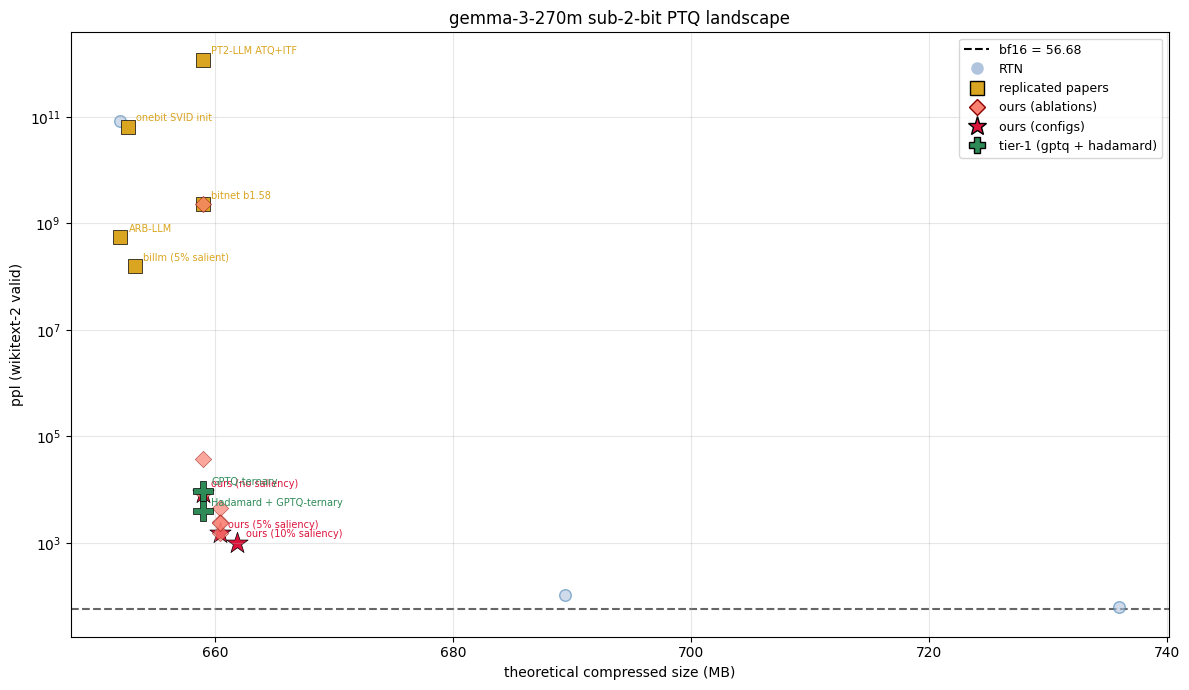

saved final_landscape.png and all_results_final.jsonl


In [24]:
# combine everything
all_results = {
    'rtn':       [r for r in results if r['group'] == 'all_linear'],
    'sota':      sota_results,
    'ours':      ours_results,
    'ablation':  ablation_results,
    'tier1':     tier1_results,
}

# print master table
print(f"{'method':52s} {'ppl':>14s} {'size_MB':>10s} {'bits':>6s}")
print('-' * 90)
all_flat = []
for k, lst in all_results.items():
    for r in lst:
        all_flat.append((k, r))
for k, r in sorted(all_flat, key=lambda x: x[1]['ppl']):
    method = r.get('method', '')
    label = r['label'] if 'label' in r else f"{method}"
    if k == 'rtn':
        label = f'RTN {method}'
    print(f"[{k:8s}] {label:42s} {r['ppl']:14.3f} {r['size_mb']:10.2f} {r['bits']:>6.2f}")

with open('all_results_final.jsonl', 'w') as f:
    for k, r in all_flat:
        rec = dict(r); rec['family'] = k
        f.write(json.dumps(rec) + '\n')


# plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.axhline(ppl_bf16, color='black', linestyle='--', alpha=0.6, zorder=0,
           label=f'bf16 = {ppl_bf16:.2f}')

style = {
    'rtn':      dict(marker='o', s=70,  color='lightsteelblue', alpha=0.6, edgecolor='steelblue'),
    'sota':     dict(marker='s', s=110, color='goldenrod',     edgecolor='black', linewidth=0.5),
    'ours':     dict(marker='*', s=260, color='crimson',       edgecolor='black', linewidth=0.5),
    'ablation': dict(marker='D', s=70,  color='salmon',        edgecolor='darkred', linewidth=0.4, alpha=0.7),
    'tier1':    dict(marker='P', s=200, color='seagreen',      edgecolor='black', linewidth=0.5),
}

for k, lst in all_results.items():
    for r in lst:
        ax.scatter(r['size_mb'], r['ppl'], **style[k])
        # only label important points
        if k in ('sota', 'ours', 'tier1'):
            label = r.get('label', r.get('method', ''))
            ax.annotate(label, (r['size_mb'], r['ppl']),
                        fontsize=7, xytext=(6, 4), textcoords='offset points',
                        color=style[k]['color'])

ax.set_xlabel('theoretical compressed size (MB)')
ax.set_ylabel('ppl (wikitext-2 valid)')
ax.set_yscale('log')
ax.set_title('gemma-3-270m sub-2-bit PTQ landscape')

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='black', linestyle='--', label=f'bf16 = {ppl_bf16:.2f}'),
    Line2D([0], [0], marker='o', linestyle='', color='lightsteelblue', markersize=8, label='RTN'),
    Line2D([0], [0], marker='s', linestyle='', color='goldenrod', markersize=10,
           markeredgecolor='black', label='replicated papers'),
    Line2D([0], [0], marker='D', linestyle='', color='salmon', markersize=8,
           markeredgecolor='darkred', label='ours (ablations)'),
    Line2D([0], [0], marker='*', linestyle='', color='crimson', markersize=14,
           markeredgecolor='black', label='ours (configs)'),
    Line2D([0], [0], marker='P', linestyle='', color='seagreen', markersize=12,
           markeredgecolor='black', label='tier-1 (gptq + hadamard)'),
]
ax.legend(handles=handles, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_landscape.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved final_landscape.png and all_results_final.jsonl')

## takeaways for the writeup

once the run completes, the master table tells me:

1. **naive sub-2-bit PTQ fails hard.**  
   bf16 is the reference. int8 stays close. int4 gets worse but is still much better than ternary/binary. plain 1.58-bit and 1-bit RTN collapse badly.

2. **the paper-inspired baselines are useful, but not full replications.**  
   i should not write “replicated BitNet / BiLLM / PT2-LLM.” the honest phrase is “simplified paper-inspired baseline.” these cells isolate the core idea, but not the full engineering of the papers.

3. **ATQ can improve local RMSE and still fail on PPL.**  
   this is one of the main research lessons. better local weight reconstruction does not automatically mean the model’s computation is preserved.

4. **saliency rescue is the biggest lever so far.**  
   the best result comes from keeping a small fraction of important weights at higher precision. 10% saliency rescue beats 5%, and both beat no-saliency.

5. **the method is not pure 1.58-bit.**  
   it is mixed precision. most weights are pushed toward ternary, but some important weights need INT4 rescue. that is the honest framing.

6. **GPTQ / Hadamard still need a cleaner implementation.**  
   the simplified baseline is useful as a sanity check, but not enough to make strong claims. next step is proper GPTQ, real rotation folding, and layerwise saliency schedules.

7. **compute note.**  
   the pipeline was first built and checked locally. local evaluation worked, but repeated sweeps were slow, so i used remaining colab credits from a course to run more ablations faster. that should go in the README/top note so the experiment setup is clear.

best github framing:

this is an in-progress research notebook on why sub-2-bit PTQ fails on gemma-270m and which corrections help. not a finished compressor, not a full paper replication, and not real low-bit inference yet.

next steps:
- clean code into `src/quant/`
- add proper GPTQ
- implement real Hadamard / rotation folding
- sweep saliency percentage per layer
- try layer skipping for fragile modules
- compare against real int4 GPTQ
- eventually test actual low-bit storage / inference path